- valid values should be in the range [UK, USA, Greece], string

- valid values should be in the range [Male, Female], string

- valid values should be in the range [16-64], numeric

- valid values should be in the range [HTC, iPhone, Microsoft, Samsung, Other], string, where country is in range [UK, USA], string

- valid values should be in the range [None, One, Two, Three or more, Prefer not to say], string

- different salary ranges, string

- valid values should be in the range[Android, iOS (for iPhone), Windows phone / Windows 10, Other / Don’t know], string, where country is in range [UK, USA], string


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load the CSV files
labels_df = pd.read_csv('labels.csv')
raw_df = pd.read_csv('raw_export.csv')

In [ ]:
labels_df

,Question ID,Question Code,Question,Base option,Precode
0,q1_1,q1,What country do you live in currently?,UK,1
1,q1_2,q1,What country do you live in currently?,USA,2
2,q1_3,q1,What country do you live in currently?,Greece,3
3,q2_1,q2,Which of the following best describes your gen...,Male,1
4,q2_2,q2,Which of the following best describes your gen...,Female,2
...,...,...,...,...,...
97,q6_14,q6,What is your yearly household income before ta...,"125,001 EUR or more",14
98,q7_1,q7,What operating system do you use on the follow...,Android,1
99,q7_2,q7,What operating system do you use on the follow...,iOS (for iPhone),2
100,q7_3,q7,What operating system do you use on the follow...,Windows phone / Windows 10,3


In [ ]:
labels_df.isnull().sum().sort_values(ascending=False)

,0
Base option,1
Question ID,0
Question Code,0
Question,0
Precode,0


In [ ]:
labels_df[labels_df.isnull().any(axis=1)]

,Question ID,Question Code,Question,Base option,Precode
65,q4a_1,q4a,How many houses / properties do you own?,NaN,1


In [ ]:
labels_df['Question ID'].unique()

array(['q1_1', 'q1_2', 'q1_3', 'q2_1', 'q2_2', 'q3_16', 'q3_17', 'q3_18',
       'q3_19', 'q3_20', 'q3_21', 'q3_22', 'q3_23', 'q3_24', 'q3_25',
       'q3_26', 'q3_27', 'q3_28', 'q3_29', 'q3_30', 'q3_31', 'q3_32',
       'q3_33', 'q3_34', 'q3_35', 'q3_36', 'q3_37', 'q3_38', 'q3_39',
       'q3_40', 'q3_41', 'q3_42', 'q3_43', 'q3_44', 'q3_45', 'q3_46',
       'q3_47', 'q3_48', 'q3_49', 'q3_50', 'q3_51', 'q3_52', 'q3_53',
       'q3_54', 'q3_55', 'q3_56', 'q3_57', 'q3_58', 'q3_59', 'q3_60',
       'q3_61', 'q3_62', 'q3_63', 'q3_64', 'q3a_1', 'q3a_2', 'q3a_3',
       'q3a_4', 'q3a_5', 'q3a_6', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q4_5',
       'q4a_1', 'q4a_2', 'q4a_3', 'q4a_4', 'q4a_5', 'q5_1', 'q5_2',
       'q5_3', 'q5_4', 'q5_5', 'q5_6', 'q5_7', 'q5_8', 'q5_9', 'q5_10',
       'q5_11', 'q5_12', 'q5_13', 'q5_14', 'q6_1', 'q6_2', 'q6_4', 'q6_5',
       'q6_3', 'q6_6', 'q6_7', 'q6_8', 'q6_9', 'q6_10', 'q6_11', 'q6_12',
       'q6_13', 'q6_14', 'q7_1', 'q7_2', 'q7_3', 'q7_4'], dtype=object)

In [ ]:
labels_df['Question Code'].unique()

array(['q1', 'q2', 'q3', 'q3a', 'q4', 'q4a', 'q5', 'q6', 'q7'],
      dtype=object)

In [ ]:
labels_df['Question'].unique()

array(['What country do you live in currently?',
       'Which of the following best describes your gender?',
       'How old are you?', 'Age groups',
       'Which of the following mobile brands do you currently own? If you own multiple, please select your favourite one. (Only asked in the UK and USA)',
       'How many houses / properties do you own?',
       'What is your yearly household income before tax or any other deductions? Please think about the income of your entire household each year (not each month).',
       'What operating system do you use on the following device: Smartphone / Mobile phone? If you own multiple phones, please answer about your favourite one. (Only asked in the UK and USA)'],
      dtype=object)

In [ ]:
labels_df['Base option'].unique()

array(['UK', 'USA', 'Greece', 'Male', 'Female', '16', '17', '18', '19',
       '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30',
       '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41',
       '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52',
       '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63',
       '64', '16-20', '20-29', '30-39', '40-49', '50-59', '60-65', 'HTC',
       'iPhone', 'Microsoft', 'Samsung', 'Other', nan, 'One', 'Two',
       'Three or more', 'Prefer not to say', '2,500 EUR or less',
       '2,501 to 10,000 EUR', '10,001 to 17,000 EUR',
       '17,001 to 22,000 EUR', '22,001 to 27,000 EUR',
       '27,001 to 30,000 EUR', '30,001 to 37,000 EUR',
       '37,001 to 45,000 EUR', '45,001 to 55,000 EUR',
       '55,001 to 90,000 EUR', "Don't know", '90,001 to 125,000 EUR',
       '125,001 EUR or more', '10,001 to 20,000 EUR',
       '20,001 to 25,000 EUR', '25,001 to 32,000 EUR',
       '32,001 to 40,000 EUR'

In [ ]:
labels_df['Precode'].unique()

array([ 1,  2,  3, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
       30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
       64,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [ ]:
question_groups = {
    code: group_df
    for code, group_df in labels_df.groupby('Question Code')
}
question_codes = ['q1', 'q2', 'q3', 'q3a', 'q4', 'q4a', 'q5', 'q6', 'q7']
total_rows = sum(question_groups[code].shape[0] for code in question_codes)
print("Total rows:", total_rows)

Total rows: 102


In [ ]:
question_groups['q1']  # DataFrame for Question 1

,Question ID,Question Code,Question,Base option,Precode
0,q1_1,q1,What country do you live in currently?,UK,1
1,q1_2,q1,What country do you live in currently?,USA,2
2,q1_3,q1,What country do you live in currently?,Greece,3


In [ ]:
question_groups['q2']  # DataFrame for Question 2

,Question ID,Question Code,Question,Base option,Precode
3,q2_1,q2,Which of the following best describes your gen...,Male,1
4,q2_2,q2,Which of the following best describes your gen...,Female,2


In [ ]:
question_groups['q3']  # DataFrame for Question 3

,Question ID,Question Code,Question,Base option,Precode
5,q3_16,q3,How old are you?,16,16
6,q3_17,q3,How old are you?,17,17
7,q3_18,q3,How old are you?,18,18
8,q3_19,q3,How old are you?,19,19
9,q3_20,q3,How old are you?,20,20
10,q3_21,q3,How old are you?,21,21
11,q3_22,q3,How old are you?,22,22
12,q3_23,q3,How old are you?,23,23
13,q3_24,q3,How old are you?,24,24
14,q3_25,q3,How old are you?,25,25


In [ ]:
question_groups['q3a']  # DataFrame for Question 3a

,Question ID,Question Code,Question,Base option,Precode
54,q3a_1,q3a,Age groups,16-20,1
55,q3a_2,q3a,Age groups,20-29,2
56,q3a_3,q3a,Age groups,30-39,3
57,q3a_4,q3a,Age groups,40-49,4
58,q3a_5,q3a,Age groups,50-59,5
59,q3a_6,q3a,Age groups,60-65,6


In [ ]:
question_groups['q4']  # DataFrame for Question 4

,Question ID,Question Code,Question,Base option,Precode
60,q4_1,q4,Which of the following mobile brands do you cu...,HTC,1
61,q4_2,q4,Which of the following mobile brands do you cu...,iPhone,2
62,q4_3,q4,Which of the following mobile brands do you cu...,Microsoft,3
63,q4_4,q4,Which of the following mobile brands do you cu...,Samsung,4
64,q4_5,q4,Which of the following mobile brands do you cu...,Other,5


In [ ]:
question_groups['q4a']  # DataFrame for Question 4a

,Question ID,Question Code,Question,Base option,Precode
65,q4a_1,q4a,How many houses / properties do you own?,NaN,1
66,q4a_2,q4a,How many houses / properties do you own?,One,2
67,q4a_3,q4a,How many houses / properties do you own?,Two,3
68,q4a_4,q4a,How many houses / properties do you own?,Three or more,4
69,q4a_5,q4a,How many houses / properties do you own?,Prefer not to say,5


In [ ]:
question_groups['q5']  # DataFrame for Question 5

,Question ID,Question Code,Question,Base option,Precode
70,q5_1,q5,What is your yearly household income before ta...,"2,500 EUR or less",1
71,q5_2,q5,What is your yearly household income before ta...,"2,501 to 10,000 EUR",2
72,q5_3,q5,What is your yearly household income before ta...,"10,001 to 17,000 EUR",3
73,q5_4,q5,What is your yearly household income before ta...,"17,001 to 22,000 EUR",4
74,q5_5,q5,What is your yearly household income before ta...,"22,001 to 27,000 EUR",5
75,q5_6,q5,What is your yearly household income before ta...,"27,001 to 30,000 EUR",6
76,q5_7,q5,What is your yearly household income before ta...,"30,001 to 37,000 EUR",7
77,q5_8,q5,What is your yearly household income before ta...,"37,001 to 45,000 EUR",8
78,q5_9,q5,What is your yearly household income before ta...,"45,001 to 55,000 EUR",9
79,q5_10,q5,What is your yearly household income before ta...,"55,001 to 90,000 EUR",10


In [ ]:
question_groups['q6']  # DataFrame for Question 6

,Question ID,Question Code,Question,Base option,Precode
84,q6_1,q6,What is your yearly household income before ta...,"2,500 EUR or less",1
85,q6_2,q6,What is your yearly household income before ta...,"2,501 to 10,000 EUR",2
86,q6_4,q6,What is your yearly household income before ta...,"10,001 to 20,000 EUR",4
87,q6_5,q6,What is your yearly household income before ta...,"20,001 to 25,000 EUR",5
88,q6_3,q6,What is your yearly household income before ta...,"25,001 to 32,000 EUR",3
89,q6_6,q6,What is your yearly household income before ta...,"32,001 to 40,000 EUR",6
90,q6_7,q6,What is your yearly household income before ta...,"40,001 to 50,000 EUR",7
91,q6_8,q6,What is your yearly household income before ta...,"50,001 to 60,000 EUR",8
92,q6_9,q6,What is your yearly household income before ta...,"60,001 to 75,000 EUR",9
93,q6_10,q6,What is your yearly household income before ta...,"75,001 to 100,000 EUR",10


In [ ]:
question_groups['q7']  # DataFrame for Question 7

,Question ID,Question Code,Question,Base option,Precode
98,q7_1,q7,What operating system do you use on the follow...,Android,1
99,q7_2,q7,What operating system do you use on the follow...,iOS (for iPhone),2
100,q7_3,q7,What operating system do you use on the follow...,Windows phone / Windows 10,3
101,q7_4,q7,What operating system do you use on the follow...,Other / Don't know,4


In [ ]:
raw_df

,ID number,question_code,answer_code
0,1,Country,UK
1,2,Country,UK
2,3,Country,UK
3,4,Country,USA
4,5,Country,USA
...,...,...,...
2595,196,q7,1
2596,197,q7,2
2597,198,q7,2
2598,199,q7,2


In [ ]:
raw_df.isnull().sum().sort_values(ascending=False)
raw_df[raw_df.isnull().any(axis=1)]
null_counts = raw_df[raw_df['answer_code'].isnull()].groupby('question_code').size()
print(null_counts)

question_code
q2      7
q5    100
q6    100
dtype: int64


In [ ]:
raw_df[raw_df.isnull().any(axis=1)]

,ID number,question_code,answer_code
407,8,q2,NaN
419,20,q2,NaN
548,149,q2,NaN
572,173,q2,NaN
585,186,q2,NaN
...,...,...,...
2393,194,q6,NaN
2394,195,q6,NaN
2395,196,q6,NaN
2397,198,q6,NaN


In [ ]:
# Filter rows with null answer_code
null_entries = raw_df[raw_df['answer_code'].isnull()]

# Group by question_code and display
for question, group in null_entries.groupby('question_code'):
    print(f"\n=== Null Responses for Question: {question} ===")
    display(group)


=== Null Responses for Question: q2 ===


,ID number,question_code,answer_code
407,8,q2,NaN
419,20,q2,NaN
548,149,q2,NaN
572,173,q2,NaN
585,186,q2,NaN
590,191,q2,NaN
594,195,q2,NaN



=== Null Responses for Question: q5 ===


,ID number,question_code,answer_code
2001,2,q5,NaN
2004,5,q5,NaN
2005,6,q5,NaN
2007,8,q5,NaN
2011,12,q5,NaN
...,...,...,...
2189,190,q5,NaN
2190,191,q5,NaN
2192,193,q5,NaN
2196,197,q5,NaN



=== Null Responses for Question: q6 ===


,ID number,question_code,answer_code
2200,1,q6,NaN
2202,3,q6,NaN
2203,4,q6,NaN
2206,7,q6,NaN
2208,9,q6,NaN
...,...,...,...
2393,194,q6,NaN
2394,195,q6,NaN
2395,196,q6,NaN
2397,198,q6,NaN


In [ ]:
summary = raw_df.groupby('question_code')['answer_code'].agg(
    total_responses='count',
    null_responses=lambda x: x.isnull().sum()
)
print(summary)

               total_responses  null_responses
question_code                                 
Country                    200               0
q1                         200               0
q2                         193               7
q3                         200               0
q4                         200               0
q4a_1                      200               0
q4a_2                      200               0
q4a_3                      200               0
q4a_4                      200               0
q4a_5                      200               0
q5                         100             100
q6                         100             100
q7                         200               0


In [ ]:
raw_df['ID number'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [ ]:
raw_df['question_code'].unique()

array(['Country', 'q1', 'q2', 'q3', 'q4', 'q4a_1', 'q4a_2', 'q4a_3',
       'q4a_4', 'q4a_5', 'q5', 'q6', 'q7'], dtype=object)

In [ ]:
raw_df['answer_code'].unique()

array(['UK', 'USA', 'Greece', 'Japan', '1', '2', '3', '4', '2.0', '1.0',
       nan, '61', '22', '30', '38', '39', '20', '34', '58', '51', '24',
       '18', '82', '36', '50', '33', '27', '57', '43', '47', '64', '72',
       '41', '31', '62', '46', '53', '48', '52', '26', '54', '55', '45',
       '23', '59', '63', '25', '37', '56', '21', '42', '14', '28', '65',
       '19', '17', '60', '40', '35', '49', '29', '68', '32', '5', '0',
       '21.0', '4.0', '9.0', '8.0', '10.0', '13.0', '6.0', '11.0', '7.0',
       '14.0', '20.0', '19.0', '15.0', '12.0', '16.0', '5.0', '17.0',
       '22.0', '18.0'], dtype=object)

In [ ]:
question_code_groups = {
    code: group_df
    for code, group_df in raw_df.groupby('question_code')
}
question_codes = ['Country', 'q1', 'q2', 'q3', 'q4', 'q4a_1', 'q4a_2', 'q4a_3',
       'q4a_4', 'q4a_5', 'q5', 'q6', 'q7']
total_rows = sum(question_code_groups[code].shape[0] for code in question_codes)
print("Total rows:", total_rows)

Total rows: 2600


In [ ]:
question_code_groups['Country']
raw_df[raw_df['question_code'] == 'Country']['answer_code'].unique()
valid_countries = ['UK', 'USA', 'Greece']
# Filter the Country question rows
country_answers = raw_df[raw_df['question_code'] == 'Country']
# Find any invalid values
invalid_countries = country_answers[~country_answers['answer_code'].isin(valid_countries)]
print("Invalid country entries:")
print(invalid_countries)

Invalid country entries:
     ID number question_code answer_code
55          56       Country       Japan
56          57       Country       Japan
57          58       Country       Japan
58          59       Country       Japan
182        183       Country       Japan
183        184       Country       Japan


answer_code
USA       80
UK        77
Greece    37
Japan      6
Name: count, dtype: int64


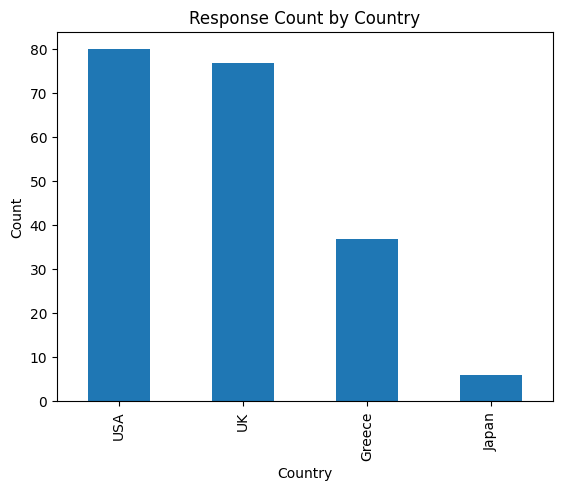

In [ ]:
country_counts = raw_df[raw_df['question_code'] == 'Country']['answer_code'].value_counts()
print(country_counts)
country_counts.plot(kind='bar', title='Response Count by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

In [ ]:
question_code_groups['q1']
raw_df[raw_df['question_code'] == 'q1']['answer_code'].unique()
country_counts = raw_df[raw_df['question_code'] == 'q1']['answer_code'].value_counts()
print(country_counts)

answer_code
2    80
1    77
3    37
4     6
Name: count, dtype: int64


In [ ]:
question_code_groups['q2']
raw_df[raw_df['question_code'] == 'q2']['answer_code'].unique()
q2_counts = raw_df[raw_df['question_code'] == 'q2']['answer_code'].value_counts(dropna=False)
print(q2_counts)

answer_code
2.0    119
1.0     74
NaN      7
Name: count, dtype: int64


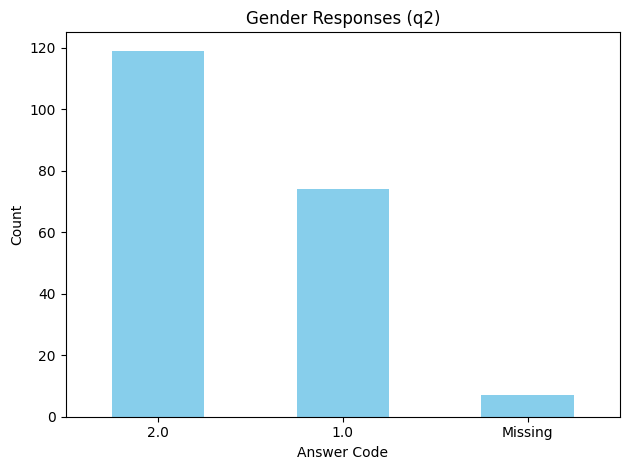

In [ ]:
# Count values with nulls included
q2_counts = raw_df[raw_df['question_code'] == 'q2']['answer_code'].value_counts(dropna=False)
# Replace NaN with a label for the plot
q2_counts.index = q2_counts.index.fillna('Missing')
# Plot
q2_counts.plot(kind='bar', color='skyblue', title='Gender Responses (q2)', rot=0)
plt.xlabel('Answer Code')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
missing_q2 = raw_df[(raw_df['question_code'] == 'q2') & (raw_df['answer_code'].isnull())]
print(missing_q2)

     ID number question_code answer_code
407          8            q2         NaN
419         20            q2         NaN
548        149            q2         NaN
572        173            q2         NaN
585        186            q2         NaN
590        191            q2         NaN
594        195            q2         NaN


In [ ]:
question_code_groups['q3']
raw_df[raw_df['question_code'] == 'q3']['answer_code'].unique()
q3_counts = raw_df[raw_df['question_code'] == 'q3']['answer_code'].value_counts(dropna=False)
print(q3_counts)

answer_code
38    9
36    8
20    7
30    7
64    7
27    6
58    6
34    6
53    6
37    6
62    6
33    5
31    5
47    5
54    5
28    5
50    5
18    5
43    4
61    4
63    4
40    4
55    4
57    4
39    4
51    4
52    4
45    4
35    4
46    4
49    4
17    3
19    3
60    3
41    3
26    3
42    2
24    2
22    2
56    2
59    2
29    2
21    2
25    2
82    1
23    1
72    1
48    1
65    1
14    1
68    1
32    1
Name: count, dtype: int64


In [ ]:
# Filter for q3
q3_data = raw_df[raw_df['question_code'] == 'q3'].copy()
# Convert answer_code to numeric (force errors to NaN)
q3_data['answer_code'] = pd.to_numeric(q3_data['answer_code'], errors='coerce')
# Find values outside the valid age range
invalid_or_missing_ages = q3_data[
    (q3_data['answer_code'] < 16) |
    (q3_data['answer_code'] > 64) |
    (q3_data['answer_code'].isnull())
]
print(invalid_or_missing_ages)

     ID number question_code  answer_code
613         14            q3           82
624         25            q3           72
683         84            q3           14
689         90            q3           65
774        175            q3           68


In [ ]:
question_code_groups['q4']
raw_df[raw_df['question_code'] == 'q4']['answer_code'].unique()
q4_counts = raw_df[raw_df['question_code'] == 'q4']['answer_code'].value_counts(dropna=False)
print(q4_counts)

answer_code
4    91
1    46
2    42
3    12
5     9
Name: count, dtype: int64


In [ ]:
# Get respondent IDs who answered q4
q4_respondents = raw_df[raw_df['question_code'] == 'q4']['ID number'].unique()
# Filter Country answers only
country_data = raw_df[raw_df['question_code'] == 'Country'][['ID number', 'answer_code']]
# Filter country info only for respondents who answered q4
q4_countries = country_data[country_data['ID number'].isin(q4_respondents)]
# Check if all countries are UK or USA
invalid_countries = q4_countries[~q4_countries['answer_code'].isin(['UK', 'USA'])]
print("Respondents answering q4 who are NOT in UK or USA:")
print(invalid_countries)

Respondents answering q4 who are NOT in UK or USA:
     ID number answer_code
5            6      Greece
10          11      Greece
11          12      Greece
16          17      Greece
20          21      Greece
23          24      Greece
27          28      Greece
33          34      Greece
55          56       Japan
56          57       Japan
57          58       Japan
58          59       Japan
73          74      Greece
74          75      Greece
75          76      Greece
76          77      Greece
77          78      Greece
78          79      Greece
79          80      Greece
80          81      Greece
81          82      Greece
82          83      Greece
84          85      Greece
89          90      Greece
90          91      Greece
95          96      Greece
99         100      Greece
102        103      Greece
105        106      Greece
109        110      Greece
115        116      Greece
182        183       Japan
183        184       Japan
190        191      Greece
191 

In [ ]:
if invalid_countries.empty:
    print("All q4 respondents are from UK or USA.")
else:
    print(f"There are {len(invalid_countries)} respondents outside UK/USA answering q4.")

There are 43 respondents outside UK/USA answering q4.


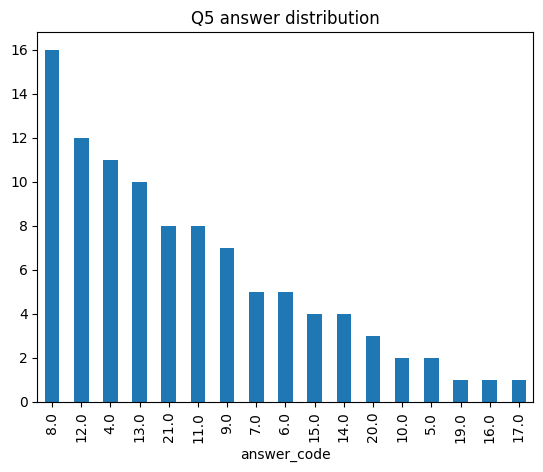

In [ ]:
question_code_groups['q5']
raw_df[raw_df['question_code'] == 'q5']['answer_code'].unique()
q5_df = raw_df[raw_df['question_code'] == 'q5']
q5_df['answer_code'].value_counts().plot(kind='bar', title='Q5 answer distribution')
plt.show()

In [ ]:
question_code_groups['q6']
raw_df[raw_df['question_code'] == 'q6']['answer_code'].unique()

array([nan, '15.0', '6.0', '8.0', '11.0', '7.0', '21.0', '10.0', '4.0',
       '17.0', '22.0', '18.0', '14.0', '16.0', '9.0', '12.0', '19.0',
       '5.0', '13.0'], dtype=object)

In [ ]:
question_code_groups['q7']
raw_df[raw_df['question_code'] == 'q7']['answer_code'].unique()
# Get respondent IDs who answered q7
q7_respondents = raw_df[raw_df['question_code'] == 'q7']['ID number'].unique()
# Filter Country answers only
country_data = raw_df[raw_df['question_code'] == 'Country'][['ID number', 'answer_code']]
# Filter country info only for respondents who answered q7
q7_countries = country_data[country_data['ID number'].isin(q7_respondents)]
# Check if all countries are UK or USA
invalid_countries = q7_countries[~q7_countries['answer_code'].isin(['UK', 'USA'])]
print("Respondents answering q7 who are NOT in UK or USA:")
print(invalid_countries)

Respondents answering q7 who are NOT in UK or USA:
     ID number answer_code
5            6      Greece
10          11      Greece
11          12      Greece
16          17      Greece
20          21      Greece
23          24      Greece
27          28      Greece
33          34      Greece
55          56       Japan
56          57       Japan
57          58       Japan
58          59       Japan
73          74      Greece
74          75      Greece
75          76      Greece
76          77      Greece
77          78      Greece
78          79      Greece
79          80      Greece
80          81      Greece
81          82      Greece
82          83      Greece
84          85      Greece
89          90      Greece
90          91      Greece
95          96      Greece
99         100      Greece
102        103      Greece
105        106      Greece
109        110      Greece
115        116      Greece
182        183       Japan
183        184       Japan
190        191      Greece
191 

In [ ]:
if invalid_countries.empty:
    print("All q7 respondents are from UK or USA.")
else:
    print(f"There are {len(invalid_countries)} respondents outside UK/USA answering q7.")

There are 43 respondents outside UK/USA answering q7.


In [ ]:
print(raw_df.dtypes)

ID number         int64
question_code    object
answer_code      object
dtype: object


In [ ]:
print(raw_df['question_code'].value_counts())

question_code
Country    200
q1         200
q2         200
q3         200
q4         200
q4a_1      200
q4a_2      200
q4a_3      200
q4a_4      200
q4a_5      200
q5         200
q6         200
q7         200
Name: count, dtype: int64


In [ ]:
print(raw_df['answer_code'].value_counts())

answer_code
0      786
1      467
2      167
2.0    119
4      106
      ... 
72       1
82       1
68       1
65       1
32       1
Name: count, Length: 83, dtype: int64


In [ ]:
print(set(raw_df['question_code'].unique()) - set(labels_df['Question Code'].unique()))

{'q4a_1', 'q4a_3', 'q4a_2', 'q4a_4', 'q4a_5', 'Country'}


In [ ]:
cross_tab = raw_df.groupby(['question_code', 'answer_code']).size().reset_index(name='count')
print(cross_tab)

    question_code answer_code  count
0         Country      Greece     37
1         Country       Japan      6
2         Country          UK     77
3         Country         USA     80
4              q1           1     77
..            ...         ...    ...
111            q6         9.0      8
112            q7           1    130
113            q7           2     45
114            q7           3     16
115            q7           4      9

[116 rows x 3 columns]


In [ ]:
print(raw_df.duplicated().sum())

0


In [ ]:
#duplicate rows
duplicate_only = raw_df[raw_df.duplicated(keep='first')]

print(f"\nNumber of duplicated entries (excluding first): {len(duplicate_only)}")
display(duplicate_only)


Number of duplicated entries (excluding first): 0


,ID number,question_code,answer_code


In [ ]:
# Merge the label descriptions into the raw data
merged_df = raw_df.merge(labels_df, left_on='question_code', right_on='Question Code', how='left')


print(merged_df.head())

   ID number question_code answer_code Question ID Question Code Question  \
0          1       Country          UK         NaN           NaN      NaN   
1          2       Country          UK         NaN           NaN      NaN   
2          3       Country          UK         NaN           NaN      NaN   
3          4       Country         USA         NaN           NaN      NaN   
4          5       Country         USA         NaN           NaN      NaN   

  Base option  Precode  
0         NaN      NaN  
1         NaN      NaN  
2         NaN      NaN  
3         NaN      NaN  
4         NaN      NaN  


In [ ]:
# Check unique question codes in raw_df and in labels_df
raw_questions = set(raw_df['question_code'].unique())
label_questions = set(labels_df['Question Code'].unique())


print("\n=== Questions in raw_export.csv not in labels.csv ===")
print(raw_questions - label_questions)

print("\n=== Questions in labels.csv not in raw_export.csv ===")
print(label_questions - raw_questions)


=== Questions in raw_export.csv not in labels.csv ===
{'q4a_1', 'q4a_3', 'q4a_2', 'q4a_4', 'q4a_5', 'Country'}

=== Questions in labels.csv not in raw_export.csv ===
{'q3a', 'q4a'}


In [ ]:
# Check answer_code ranges
print("\n=== Unique answer codes per question in raw_export.csv ===")
print(raw_df.groupby('question_code')['answer_code'].nunique())


=== Unique answer codes per question in raw_export.csv ===
question_code
Country     4
q1          4
q2          2
q3         52
q4          5
q4a_1       2
q4a_2       2
q4a_3       2
q4a_4       2
q4a_5       2
q5         17
q6         18
q7          4
Name: answer_code, dtype: int64


In [ ]:
# Merge raw data with labels
merged_df = raw_df.merge(labels_df, left_on='question_code', right_on='Question Code', how='left')
merged_df

,ID number,question_code,answer_code,Question ID,Question Code,Question,Base option,Precode
0,1,Country,UK,NaN,NaN,NaN,NaN,NaN
1,2,Country,UK,NaN,NaN,NaN,NaN,NaN
2,3,Country,UK,NaN,NaN,NaN,NaN,NaN
3,4,Country,USA,NaN,NaN,NaN,NaN,NaN
4,5,Country,USA,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
19395,199,q7,2,q7_4,q7,What operating system do you use on the follow...,Other / Don't know,4.0
19396,200,q7,1,q7_1,q7,What operating system do you use on the follow...,Android,1.0
19397,200,q7,1,q7_2,q7,What operating system do you use on the follow...,iOS (for iPhone),2.0
19398,200,q7,1,q7_3,q7,What operating system do you use on the follow...,Windows phone / Windows 10,3.0


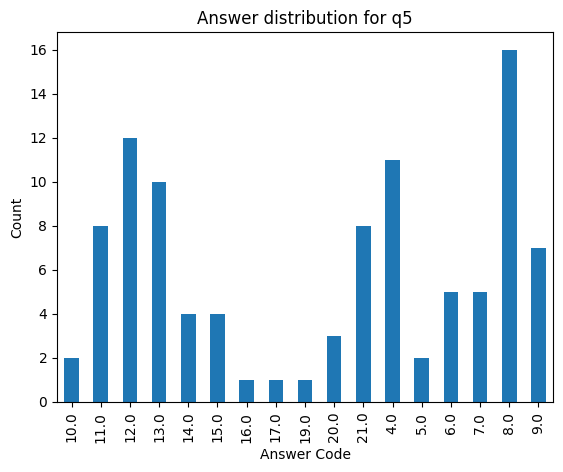

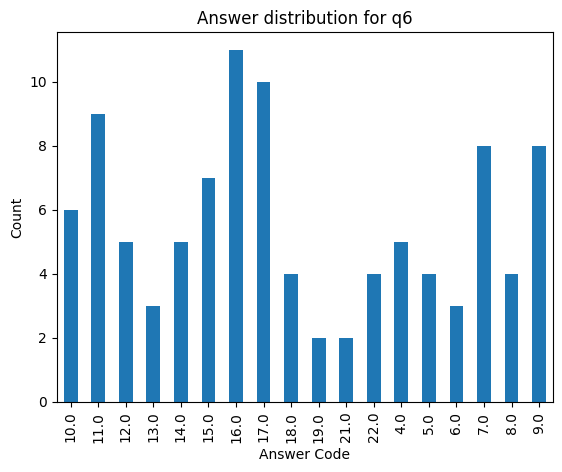

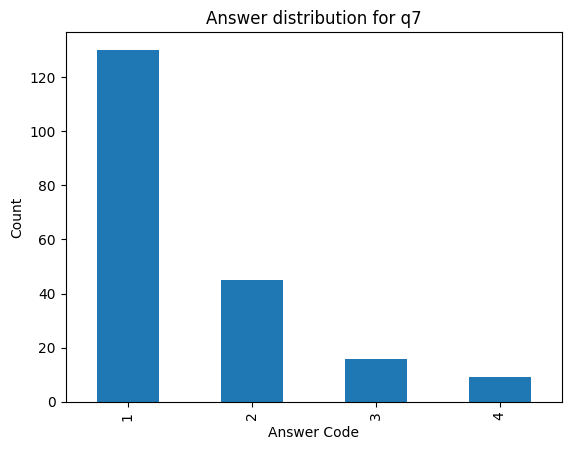

In [ ]:
# Visualize answer distribution for a few key questions
for q in ['q5', 'q6', 'q7']:
    subset = raw_df[raw_df['question_code'] == q]
    if not subset.empty:
        plt.figure()
        subset['answer_code'].value_counts().sort_index().plot(kind='bar', title=f'Answer distribution for {q}')
        plt.xlabel('Answer Code')
        plt.ylabel('Count')
        plt.show()

In [ ]:
# 1. Inspect dataset metadata
def inspect_metadata(df, name="DataFrame"):
    print(f"\n{name}.shape: {df.shape}")
    print(f"\n{name}.info():")
    print(df.info())
    print(f"\n{name}.columns: {df.columns.tolist()}")
    print(f"\n{name} head:\n{df.head()}")

# 2. Null summary
def summarize_nulls(df, name="DataFrame"):
    print(f"\n=== Null Summary for {name} ===")
    print(df.isnull().sum().sort_values(ascending=False))
    print(f"\n=== Rows with Nulls in {name} ===")
    print(df[df.isnull().any(axis=1)])

# 3. Unique values in given columns
def check_uniques(df, columns):
    for col in columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())

# 4. Group rows by question code
def group_by_question_code(df, key='question_code'):
    return {code: group for code, group in df.groupby(key)}

# 5. Merge raw data with labels
def merge_labels(raw_df, labels_df):
    return raw_df.merge(labels_df, left_on='question_code', right_on='Question Code', how='left')

# 6. Compare question codes between raw and labels
def compare_question_codes(raw_df, labels_df):
    raw_questions = set(raw_df['question_code'].unique())
    label_questions = set(labels_df['Question Code'].unique())
    print("\n=== Questions in raw_export.csv not in labels.csv ===")
    print(raw_questions - label_questions)
    print("\n=== Questions in labels.csv not in raw_export.csv ===")
    print(label_questions - raw_questions)

# 7. Answer variety summary
def summarize_answers(raw_df):
    print("\n=== Unique answer codes per question ===")
    print(raw_df.groupby('question_code')['answer_code'].nunique())

# 8. Plot answer distributions for questions
def plot_answer_distribution(df, question_list):
    for q in question_list:
        subset = df[df['question_code'] == q]
        if not subset.empty:
            plt.figure()
            subset['answer_code'].value_counts(dropna=False).sort_index().plot(
                kind='bar', title=f'Answer Distribution for {q}', color='skyblue'
            )
            plt.xlabel('Answer Code')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()

# 9. Validate expected answer values for a question
def validate_values(df, question_code, valid_values):
    answers = df[df['question_code'] == question_code]
    invalid = answers[~answers['answer_code'].isin(valid_values)]
    print(f"\n=== Invalid values for {question_code} ===")
    print(invalid)

# 10. Age range check
def check_age_range(df, question_code='q3', min_age=16, max_age=64):
    data = df[df['question_code'] == question_code].copy()
    data['answer_code'] = pd.to_numeric(data['answer_code'], errors='coerce')
    invalid = data[(data['answer_code'] < min_age) | (data['answer_code'] > max_age) | (data['answer_code'].isnull())]
    print(f"\n=== Invalid or Missing Ages in {question_code} ===")
    print(invalid)

# 11. Filter by country and check eligibility
def check_respondent_country(df, question_code, allowed_countries):
    respondents = df[df['question_code'] == question_code]['ID number'].unique()
    countries = df[df['question_code'] == 'Country'][['ID number', 'answer_code']]
    relevant = countries[countries['ID number'].isin(respondents)]
    invalid = relevant[~relevant['answer_code'].isin(allowed_countries)]
    print(f"\nRespondents answering {question_code} who are NOT in allowed countries:")
    print(invalid)
    if invalid.empty:
        print("All respondents are from allowed countries.")
    else:
        print(f"{len(invalid)} respondents are from outside allowed countries.")

# 12. Check duplicates
def check_duplicates(df, name="DataFrame"):
    duplicates = df.duplicated().sum()
    print(f"\n Duplicate rows in {name}: {duplicates}")

# 13. Frequency cross tab
def cross_tab_summary(df):
    ct = df.groupby(['question_code', 'answer_code']).size().reset_index(name='count')
    print("\n=== Cross Tab Summary ===")
    print(ct)
    return ct

1. **`inspect_metadata(df, name="DataFrame")`**
   → Inspect basic shape, info, and preview of a DataFrame.

2. **`summarize_nulls(df, name="DataFrame")`**
   → Summarize null values and show rows containing nulls.

3. **`check_uniques(df, columns)`**
   → Print unique values for each column in the provided list.

4. **`group_by_question_code(df, key='question_code')`**
   → Group a DataFrame by a column (default: `'question_code'`) and return as a dictionary.

5. **`merge_labels(raw_df, labels_df)`**
   → Merge the raw responses DataFrame with the labels DataFrame on question code.

6. **`compare_question_codes(raw_df, labels_df)`**
   → Compare the unique question codes between the raw and labels datasets.

7. **`summarize_answers(raw_df)`**
   → Show the number of unique answers per question.

8. **`plot_answer_distribution(df, question_list)`**
   → Plot answer code distribution for each question in a given list.

9. **`validate_values(df, question_code, valid_values)`**
   → Identify and display invalid values for a specific question.

10. **`check_age_range(df, question_code='q3', min_age=16, max_age=64)`**
    → Validate that age responses fall within the expected range.

11. **`check_respondent_country(df, question_code, allowed_countries)`**
    → Check if respondents to a specific question are from allowed countries.

12. **`check_duplicates(df, name="DataFrame")`**
    → Count and report duplicate rows in a DataFrame.

13. **`cross_tab_summary(df)`**
    → Create and return a grouped count summary by `question_code` and `answer_code`.

Task A

EDA on labels_df

In [ ]:
inspect_metadata(labels_df, "labels_df")


labels_df.shape: (102, 5)

labels_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Question ID    102 non-null    object
 1   Question Code  102 non-null    object
 2   Question       102 non-null    object
 3   Base option    101 non-null    object
 4   Precode        102 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 4.1+ KB
None

labels_df.columns: ['Question ID', 'Question Code', 'Question', 'Base option', 'Precode']

labels_df head:
  Question ID Question Code  \
0        q1_1            q1   
1        q1_2            q1   
2        q1_3            q1   
3        q2_1            q2   
4        q2_2            q2   

                                            Question Base option  Precode  
0             What country do you live in currently?          UK        1  
1             What country do you live in curre

In [ ]:
summarize_nulls(labels_df, "labels_df")


=== Null Summary for labels_df ===
Base option      1
Question ID      0
Question Code    0
Question         0
Precode          0
dtype: int64

=== Rows with Nulls in labels_df ===
   Question ID Question Code                                  Question  \
65       q4a_1           q4a  How many houses / properties do you own?   

   Base option  Precode  
65         NaN        1  


In [ ]:
check_uniques(labels_df, ['Question ID', 'Question Code', 'Question', 'Base option', 'Precode'])


Unique values in Question ID:
['q1_1' 'q1_2' 'q1_3' 'q2_1' 'q2_2' 'q3_16' 'q3_17' 'q3_18' 'q3_19'
 'q3_20' 'q3_21' 'q3_22' 'q3_23' 'q3_24' 'q3_25' 'q3_26' 'q3_27' 'q3_28'
 'q3_29' 'q3_30' 'q3_31' 'q3_32' 'q3_33' 'q3_34' 'q3_35' 'q3_36' 'q3_37'
 'q3_38' 'q3_39' 'q3_40' 'q3_41' 'q3_42' 'q3_43' 'q3_44' 'q3_45' 'q3_46'
 'q3_47' 'q3_48' 'q3_49' 'q3_50' 'q3_51' 'q3_52' 'q3_53' 'q3_54' 'q3_55'
 'q3_56' 'q3_57' 'q3_58' 'q3_59' 'q3_60' 'q3_61' 'q3_62' 'q3_63' 'q3_64'
 'q3a_1' 'q3a_2' 'q3a_3' 'q3a_4' 'q3a_5' 'q3a_6' 'q4_1' 'q4_2' 'q4_3'
 'q4_4' 'q4_5' 'q4a_1' 'q4a_2' 'q4a_3' 'q4a_4' 'q4a_5' 'q5_1' 'q5_2'
 'q5_3' 'q5_4' 'q5_5' 'q5_6' 'q5_7' 'q5_8' 'q5_9' 'q5_10' 'q5_11' 'q5_12'
 'q5_13' 'q5_14' 'q6_1' 'q6_2' 'q6_4' 'q6_5' 'q6_3' 'q6_6' 'q6_7' 'q6_8'
 'q6_9' 'q6_10' 'q6_11' 'q6_12' 'q6_13' 'q6_14' 'q7_1' 'q7_2' 'q7_3'
 'q7_4']

Unique values in Question Code:
['q1' 'q2' 'q3' 'q3a' 'q4' 'q4a' 'q5' 'q6' 'q7']

Unique values in Question:
['What country do you live in currently?'
 'Which of the follo

In [ ]:
check_duplicates(labels_df, "labels_df")


 Duplicate rows in labels_df: 0


EDA on raw_df

In [ ]:
inspect_metadata(raw_df, "raw_df")


raw_df.shape: (2600, 3)

raw_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID number      2600 non-null   int64 
 1   question_code  2600 non-null   object
 2   answer_code    2393 non-null   object
dtypes: int64(1), object(2)
memory usage: 61.1+ KB
None

raw_df.columns: ['ID number', 'question_code', 'answer_code']

raw_df head:
   ID number question_code answer_code
0          1       Country          UK
1          2       Country          UK
2          3       Country          UK
3          4       Country         USA
4          5       Country         USA


In [ ]:
summarize_nulls(raw_df, "raw_df")


=== Null Summary for raw_df ===
answer_code      207
ID number          0
question_code      0
dtype: int64

=== Rows with Nulls in raw_df ===
      ID number question_code answer_code
407           8            q2         NaN
419          20            q2         NaN
548         149            q2         NaN
572         173            q2         NaN
585         186            q2         NaN
...         ...           ...         ...
2393        194            q6         NaN
2394        195            q6         NaN
2395        196            q6         NaN
2397        198            q6         NaN
2399        200            q6         NaN

[207 rows x 3 columns]


In [ ]:
check_duplicates(raw_df, "raw_df")


 Duplicate rows in raw_df: 0


In [ ]:
check_uniques(raw_df, ['question_code', 'answer_code'])


Unique values in question_code:
['Country' 'q1' 'q2' 'q3' 'q4' 'q4a_1' 'q4a_2' 'q4a_3' 'q4a_4' 'q4a_5'
 'q5' 'q6' 'q7']

Unique values in answer_code:
['UK' 'USA' 'Greece' 'Japan' '1' '2' '3' '4' '2.0' '1.0' nan '61' '22'
 '30' '38' '39' '20' '34' '58' '51' '24' '18' '82' '36' '50' '33' '27'
 '57' '43' '47' '64' '72' '41' '31' '62' '46' '53' '48' '52' '26' '54'
 '55' '45' '23' '59' '63' '25' '37' '56' '21' '42' '14' '28' '65' '19'
 '17' '60' '40' '35' '49' '29' '68' '32' '5' '0' '21.0' '4.0' '9.0' '8.0'
 '10.0' '13.0' '6.0' '11.0' '7.0' '14.0' '20.0' '19.0' '15.0' '12.0'
 '16.0' '5.0' '17.0' '22.0' '18.0']


In [ ]:
summarize_answers(raw_df)


=== Unique answer codes per question ===
question_code
Country     4
q1          4
q2          2
q3         52
q4          5
q4a_1       2
q4a_2       2
q4a_3       2
q4a_4       2
q4a_5       2
q5         17
q6         18
q7          4
Name: answer_code, dtype: int64


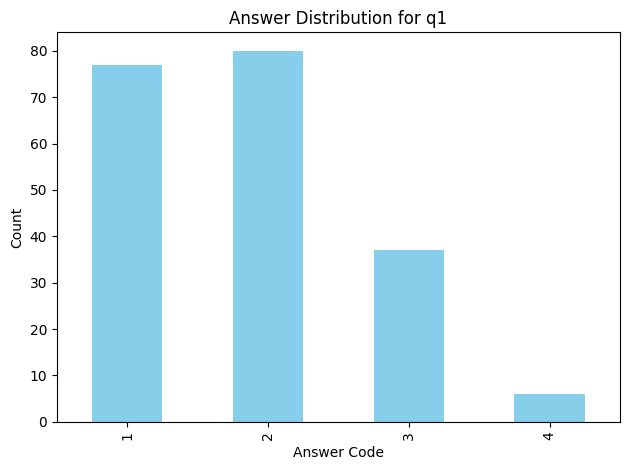

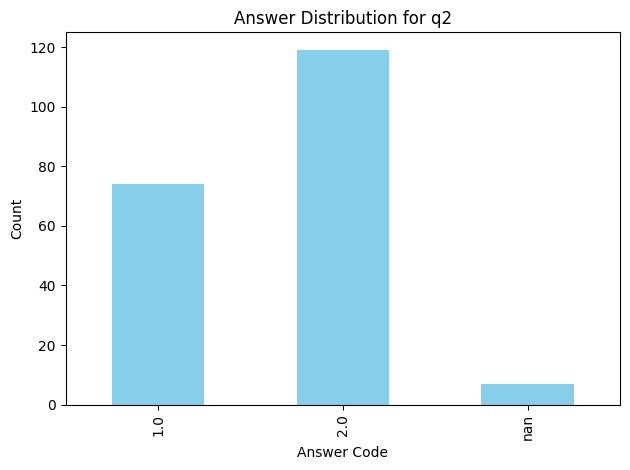

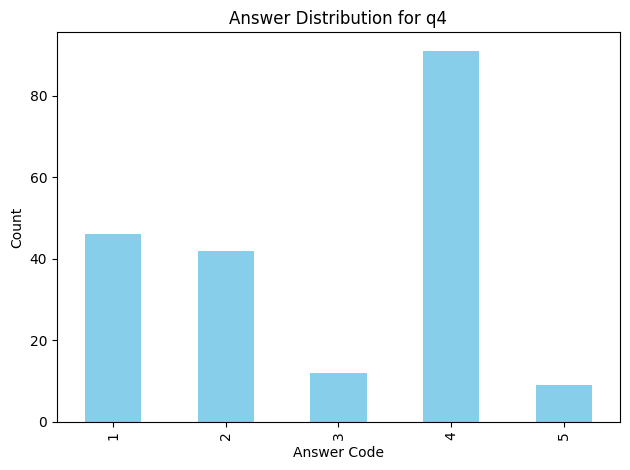

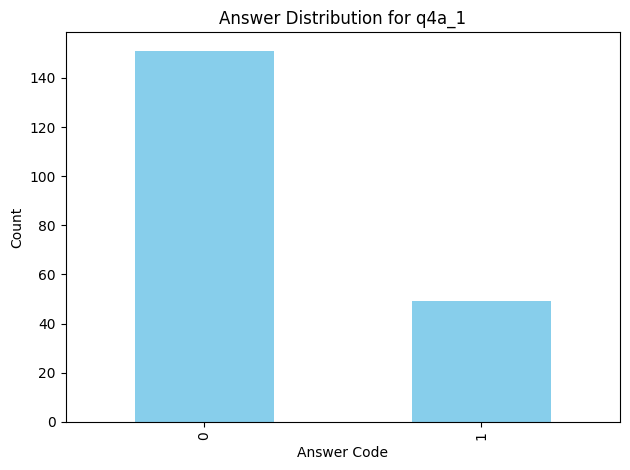

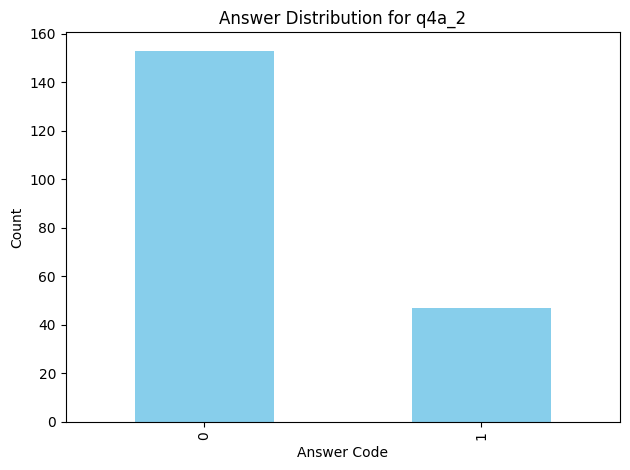

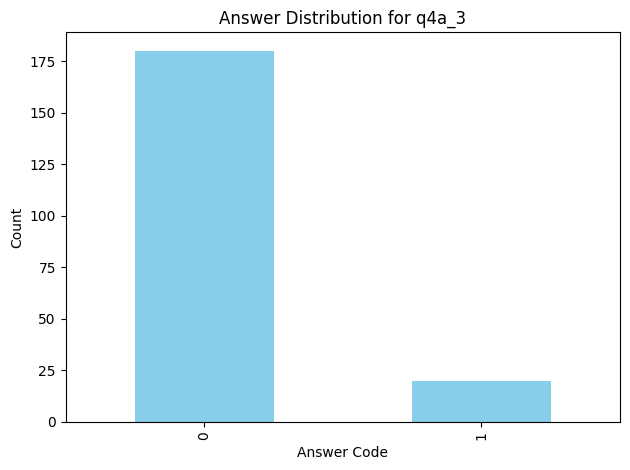

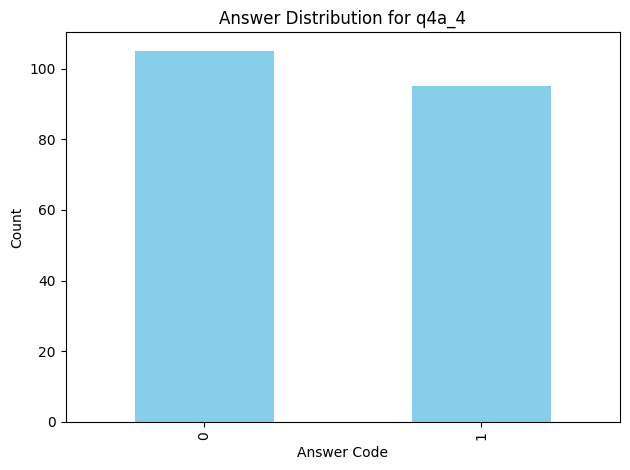

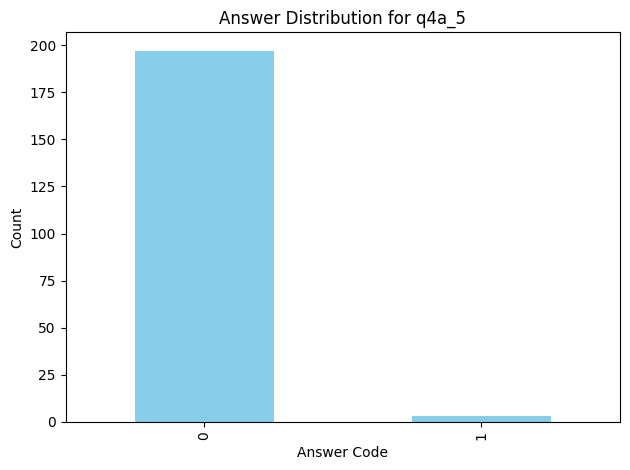

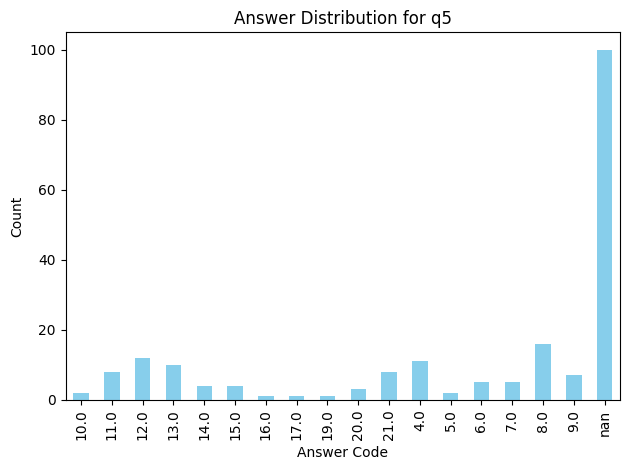

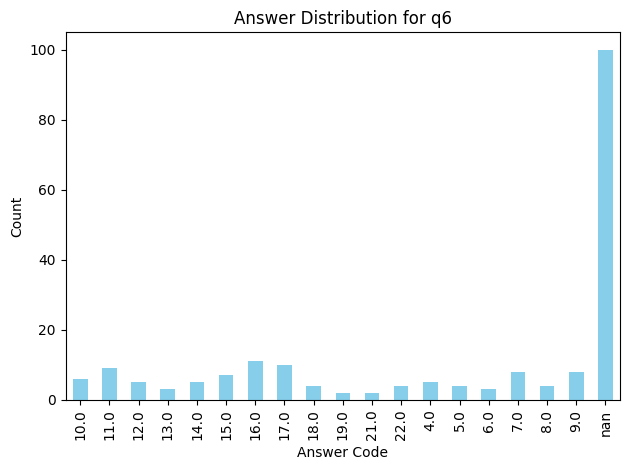

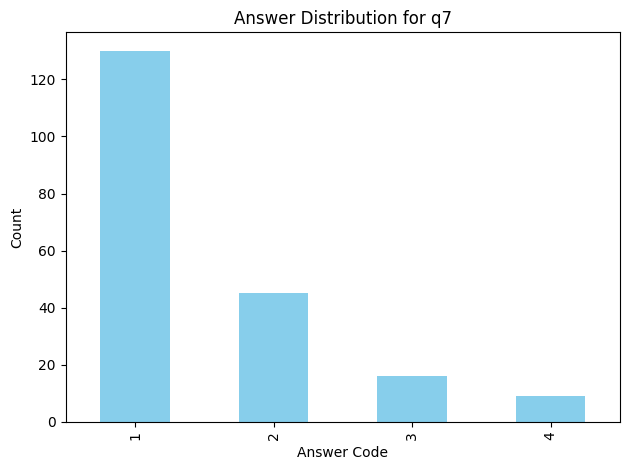

In [ ]:
plot_answer_distribution(raw_df, ['q1', 'q2', 'q4', 'q4a_1', 'q4a_2', 'q4a_3', 'q4a_4', 'q4a_5', 'q5', 'q6', 'q7'])

In [ ]:
check_age_range(raw_df, question_code='q3', min_age=16, max_age=64)


=== Invalid or Missing Ages in q3 ===
     ID number question_code  answer_code
613         14            q3           82
624         25            q3           72
683         84            q3           14
689         90            q3           65
774        175            q3           68


In [ ]:
check_respondent_country(raw_df, question_code='q1', allowed_countries=['UK', 'USA', 'Greece'])


Respondents answering q1 who are NOT in allowed countries:
     ID number answer_code
55          56       Japan
56          57       Japan
57          58       Japan
58          59       Japan
182        183       Japan
183        184       Japan
6 respondents are from outside allowed countries.


In [ ]:
check_respondent_country(raw_df, question_code='q4', allowed_countries=['UK', 'USA'])


Respondents answering q4 who are NOT in allowed countries:
     ID number answer_code
5            6      Greece
10          11      Greece
11          12      Greece
16          17      Greece
20          21      Greece
23          24      Greece
27          28      Greece
33          34      Greece
55          56       Japan
56          57       Japan
57          58       Japan
58          59       Japan
73          74      Greece
74          75      Greece
75          76      Greece
76          77      Greece
77          78      Greece
78          79      Greece
79          80      Greece
80          81      Greece
81          82      Greece
82          83      Greece
84          85      Greece
89          90      Greece
90          91      Greece
95          96      Greece
99         100      Greece
102        103      Greece
105        106      Greece
109        110      Greece
115        116      Greece
182        183       Japan
183        184       Japan
190        191      Gr

In [ ]:
check_respondent_country(raw_df, question_code='q7', allowed_countries=['UK', 'USA'])


Respondents answering q7 who are NOT in allowed countries:
     ID number answer_code
5            6      Greece
10          11      Greece
11          12      Greece
16          17      Greece
20          21      Greece
23          24      Greece
27          28      Greece
33          34      Greece
55          56       Japan
56          57       Japan
57          58       Japan
58          59       Japan
73          74      Greece
74          75      Greece
75          76      Greece
76          77      Greece
77          78      Greece
78          79      Greece
79          80      Greece
80          81      Greece
81          82      Greece
82          83      Greece
84          85      Greece
89          90      Greece
90          91      Greece
95          96      Greece
99         100      Greece
102        103      Greece
105        106      Greece
109        110      Greece
115        116      Greece
182        183       Japan
183        184       Japan
190        191      Gr

In [ ]:
validate_values(raw_df, question_code='q2', valid_values=[1, 2])


=== Invalid values for q2 ===
     ID number question_code answer_code
400          1            q2         2.0
401          2            q2         1.0
402          3            q2         2.0
403          4            q2         2.0
404          5            q2         2.0
..         ...           ...         ...
595        196            q2         1.0
596        197            q2         1.0
597        198            q2         2.0
598        199            q2         2.0
599        200            q2         2.0

[200 rows x 3 columns]


In [ ]:
validate_values(raw_df, question_code='q2', valid_values=['1.0', '2.0'])


=== Invalid values for q2 ===
     ID number question_code answer_code
407          8            q2         NaN
419         20            q2         NaN
548        149            q2         NaN
572        173            q2         NaN
585        186            q2         NaN
590        191            q2         NaN
594        195            q2         NaN


In [ ]:
cross_tab_summary(raw_df)


=== Cross Tab Summary ===
    question_code answer_code  count
0         Country      Greece     37
1         Country       Japan      6
2         Country          UK     77
3         Country         USA     80
4              q1           1     77
..            ...         ...    ...
111            q6         9.0      8
112            q7           1    130
113            q7           2     45
114            q7           3     16
115            q7           4      9

[116 rows x 3 columns]


,question_code,answer_code,count
0,Country,Greece,37
1,Country,Japan,6
2,Country,UK,77
3,Country,USA,80
4,q1,1,77
...,...,...,...
111,q6,9.0,8
112,q7,1,130
113,q7,2,45
114,q7,3,16


Findings:

- Raw data includes both Country, with actual countries in answer_code, and q1, with the index of survey option selected in answer_code

- The gender question, q2, has a different format in answer_code: floats/decimal instead of integer values, like in other questions

- Nulls and duplicates: row 65 is null: q4a_1	q4a	How many houses / properties do you own?

- There are respondents outside UK and USA who answered q4 and q7

- Small number of respondents fall outside the age range

- Some respondents answered multiple q4a_1 to q4a_4

- q4a is already in dummy/one-hot encoded format, in the raw dataset

Address the findings:

- Invalid ages in q3 : Replace invalid ages with NaN or drop them

- Multi-response in q4a_1–q4a_4	: Override with 0 and recode to q4a_5

- Check for mismatched question codes	Use compare_question_codes() and update mapping if needed

- Remove Country column before processing, as it duplicates q1 column, after checking the values align exactly

- Standardise the datatypes in answer_codes, for consistency

Task B

In [ ]:
def long_to_wide(
    df: pd.DataFrame,
    id_col: str,
    question_col: str,
    answer_col: str,
    aggfunc='first'
) -> pd.DataFrame:
    """
    Converts a long-format survey dataframe into wide format.
    Handles duplicates by aggregating answers with the specified aggfunc.

    Parameters:
        df (pd.DataFrame): Input long format DataFrame.
        id_col (str): Column name with respondent IDs.
        question_col (str): Column name with question codes.
        answer_col (str): Column name with answer codes.
        aggfunc (str or function): Aggregation function, e.g. 'first', 'max', or a function.

    Returns:
        pd.DataFrame: Wide format DataFrame.
    """

    if aggfunc == 'join_strings':
        # Custom aggregator to join multiple answers into comma-separated string
        def join_strings(x):
            # Remove NaNs and convert to string
            return ','.join(str(v) for v in x.dropna().unique())
        aggfunc_to_use = join_strings
    else:
        aggfunc_to_use = aggfunc

    wide_df = df.pivot_table(
        index=id_col,
        columns=question_col,
        values=answer_col,
        aggfunc=aggfunc_to_use
    ).reset_index()

    # Flatten MultiIndex columns if any
    if isinstance(wide_df.columns, pd.MultiIndex):
        wide_df.columns = [col if not isinstance(col, tuple) else col[-1] for col in wide_df.columns]

    return wide_df

In [ ]:
wide_df = long_to_wide(
    df=raw_df,
    id_col='ID number',
    question_col='question_code',
    answer_col='answer_code',
    aggfunc='join_strings'  # Use 'first', 'max', or 'join_strings'
)
wide_df

question_code,ID number,Country,q1,q2,q3,q4,q4a_1,q4a_2,q4a_3,q4a_4,q4a_5,q5,q6,q7
0,1,UK,1,2.0,61,4,0,0,0,1,0,21.0,,1
1,2,UK,1,1.0,22,3,0,0,1,0,0,,15.0,3
2,3,UK,1,2.0,22,1,1,0,0,0,0,4.0,,1
3,4,USA,2,2.0,30,2,0,1,0,0,0,4.0,,2
4,5,USA,2,2.0,38,1,1,0,1,0,0,,6.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,Greece,3,1.0,61,4,0,0,0,1,0,12.0,,1
196,197,Greece,3,1.0,51,1,1,0,0,0,0,,8.0,2
197,198,Greece,3,2.0,35,1,1,0,1,0,0,4.0,,2
198,199,Greece,3,2.0,29,2,0,1,0,0,0,,10.0,2


In [ ]:
# Loop through each column and print unique values
for col in wide_df.columns:
    unique_vals = wide_df[col].unique()
    print(f"{col} → {sorted(unique_vals[~pd.isnull(unique_vals)].tolist())} ({len(unique_vals)} unique values including NaNs)\n")

ID number → [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200] (200 unique values including NaNs)

Country → ['Greece', 'Japan', 'UK', 'USA'] (4 unique values

Task C

C.1  

Mobile Brand (question 4)

In [ ]:
# Filter q4 rows
q4_df = raw_df[raw_df['question_code'] == 'q4']


# Number of unique answers per respondent
unique_answers = q4_df.groupby('ID number')['answer_code'].nunique()


print("Distribution of unique answers for q4:", unique_answers.value_counts())

Distribution of unique answers for q4: answer_code
1    200
Name: count, dtype: int64


In [ ]:
# Generate binary columns for q4
q4_df = raw_df[raw_df['question_code'] == 'q4'].copy()


for i in range(1, 5):
    q4_df[f'q4_{i}'] = (q4_df['answer_code'].astype(str) == str(i)).astype(int)


# Compute the fifth column: 'Other'
#q4_df['q4_5'] = (q4_df[[f'q4_{i}' for i in range(1, 5)]].sum(axis=1) == 0).astype(int)


# Show result
print(q4_df[['ID number', 'answer_code', 'q4_1', 'q4_2', 'q4_3', 'q4_4']].head(10))

     ID number answer_code  q4_1  q4_2  q4_3  q4_4
800          1           4     0     0     0     1
801          2           3     0     0     1     0
802          3           1     1     0     0     0
803          4           2     0     1     0     0
804          5           1     1     0     0     0
805          6           5     0     0     0     0
806          7           1     1     0     0     0
807          8           3     0     0     1     0
808          9           1     1     0     0     0
809         10           4     0     0     0     1


In [ ]:
# If none of the first four columns is 1, then q4_5 is 1
q4_df['q4_5'] = (q4_df[[f'q4_{i}' for i in range(1, 5)]].sum(axis=1) == 0).astype(int)
q4_df['q4_5'].value_counts()

,count
q4_5,
0,191
1,9


In [ ]:
other_brand_users = q4_df[q4_df['q4_5'] == 1]
print(other_brand_users)

     ID number question_code answer_code  q4_1  q4_2  q4_3  q4_4  q4_5
805          6            q4           5     0     0     0     0     1
820         21            q4           5     0     0     0     0     1
849         50            q4           5     0     0     0     0     1
873         74            q4           5     0     0     0     0     1
883         84            q4           5     0     0     0     0     1
886         87            q4           5     0     0     0     0     1
907        108            q4           5     0     0     0     0     1
969        170            q4           5     0     0     0     0     1
994        195            q4           5     0     0     0     0     1


In [ ]:
# Step 1: Filter responses for Question 4
q4_df = raw_df[raw_df['question_code'] == 'q4'].copy()

# Step 2: Inspect q4 data
inspect_metadata(q4_df, name="q4_df")
summarize_nulls(q4_df, name="q4_df")
check_uniques(q4_df, ['answer_code'])

# Step 3: Check if each respondent only answered once (single-choice)
unique_answers = q4_df.groupby('ID number')['answer_code'].nunique()
print("\n Distribution of unique answers per respondent for q4:")
print(unique_answers.value_counts())

# Optional: Show respondents with more than one answer (shouldn't happen in single-choice)
multi_response_ids = unique_answers[unique_answers > 1].index
if not multi_response_ids.empty:
    print("\n Respondents who answered q4 multiple times:")
    print(q4_df[q4_df['ID number'].isin(multi_response_ids)])
else:
    print("\n All respondents answered q4 only once (single-choice).")

# Step 4: Generate binary columns for q4_1 to q4_4
for i in range(1, 5):
    q4_df[f'q4_{i}'] = (q4_df['answer_code'].astype(str) == str(i)).astype(int)

# Step 5: Generate 'Other' column as q4_5
# If none of q4_1 to q4_4 is selected, mark q4_5 as 1
q4_df['q4_5'] = (q4_df[[f'q4_{i}' for i in range(1, 5)]].sum(axis=1) == 0).astype(int)

# Step 6: Display sample results
print("\n Sample of transformed q4 responses:")
print(q4_df[['ID number', 'answer_code', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q4_5']].head(10))

# Step 7: Show frequency of "Other" responses
print("\n Count of 'Other' (q4_5 == 1):")
print(q4_df['q4_5'].value_counts())

# Optional: View all "Other" brand respondents
other_brand_users = q4_df[q4_df['q4_5'] == 1]
print("\n Respondents who selected 'Other' for q4:")
print(other_brand_users[['ID number', 'answer_code']])


q4_df.shape: (200, 3)

q4_df.info():
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 800 to 999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID number      200 non-null    int64 
 1   question_code  200 non-null    object
 2   answer_code    200 non-null    object
dtypes: int64(1), object(2)
memory usage: 6.2+ KB
None

q4_df.columns: ['ID number', 'question_code', 'answer_code']

q4_df head:
     ID number question_code answer_code
800          1            q4           4
801          2            q4           3
802          3            q4           1
803          4            q4           2
804          5            q4           1

=== Null Summary for q4_df ===
ID number        0
question_code    0
answer_code      0
dtype: int64

=== Rows with Nulls in q4_df ===
Empty DataFrame
Columns: [ID number, question_code, answer_code]
Index: []

Unique values in answer_code:
['4' '3' '1' '2' '5']

 Dist

In [ ]:
def generate_binary_columns(df, question_code, valid_range):
    q_df = df[df['question_code'] == question_code].copy()
    for val in valid_range:
        q_df[f'{question_code}_{val}'] = (q_df['answer_code'].astype(str) == str(val)).astype(int)
    q_df[f'{question_code}_5(Other)'] = (q_df[[f'{question_code}_{v}' for v in valid_range]].sum(axis=1) == 0).astype(int)
    return q_df

In [ ]:
generate_binary_columns(raw_df, 'q4', [1,2,3,4])

,ID number,question_code,answer_code,q4_1,q4_2,q4_3,q4_4,q4_5(Other)
800,1,q4,4,0,0,0,1,0
801,2,q4,3,0,0,1,0,0
802,3,q4,1,1,0,0,0,0
803,4,q4,2,0,1,0,0,0
804,5,q4,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...
995,196,q4,4,0,0,0,1,0
996,197,q4,1,1,0,0,0,0
997,198,q4,1,1,0,0,0,0
998,199,q4,2,0,1,0,0,0


C.2

Propert Ownership (question 4a)

In [ ]:
raw_df.columns

Index(['ID number', 'question_code', 'answer_code'], dtype='object')

In [ ]:
raw_df['question_code'].unique()

array(['Country', 'q1', 'q2', 'q3', 'q4', 'q4a_1', 'q4a_2', 'q4a_3',
       'q4a_4', 'q4a_5', 'q5', 'q6', 'q7'], dtype=object)

In [ ]:
wide_df = long_to_wide(
    df=raw_df,
    id_col='ID number',
    question_col='question_code',
    answer_col='answer_code',
    aggfunc='join_strings'  # Use 'first', 'max', or 'join_strings'
)
wide_df

def get_multiselect_respondents(df, base_col='q4a', valid_options=[1, 2, 3, 4], id_col='ID number'):
    """
    Returns a filtered DataFrame showing respondents who selected multiple options in a multi-select question.

    Parameters:
        df (pd.DataFrame): The wide-format DataFrame.
        base_col (str): Base column name for the multi-select group (default 'q4a').
        valid_options (list): List of option suffixes to check (e.g., [1, 2, 3, 4]).
        id_col (str): Respondent ID column.

    Returns:
        pd.DataFrame: Filtered DataFrame showing only the multi-selected respondents.
    """
    # Construct full column names
    option_cols = [f"{base_col}_{i}" for i in valid_options]

    # Ensure numeric and clean
    df[option_cols] = df[option_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

    # Sum across multi-selects
    df[f'{base_col}_sum'] = df[option_cols].sum(axis=1)

    # Filter where sum > 1
    multi_df = df[df[f'{base_col}_sum'] > 1][[id_col] + option_cols + [f'{base_col}_sum']].copy()

    # Drop helper column if not needed after viewing
    # df.drop(columns=[f'{base_col}_sum'], inplace=True)

    return multi_df

multi_q4a_df = get_multiselect_respondents(wide_df, base_col='q4a')
print(multi_q4a_df)

question_code  ID number  q4a_1  q4a_2  q4a_3  q4a_4  q4a_sum
4                      5      1      0      1      0        2
8                      9      1      1      0      0        2
24                    25      1      0      0      1        2
38                    39      0      1      0      1        2
96                    97      0      1      0      1        2
103                  104      1      1      1      0        3
109                  110      1      1      0      0        2
121                  122      0      1      0      1        2
141                  142      1      0      1      1        3
148                  149      0      1      0      1        2
166                  167      1      0      1      0        2
197                  198      1      0      1      0        2


In [ ]:
wide_df = long_to_wide(
    df=raw_df,
    id_col='ID number',
    question_col='question_code',
    answer_col='answer_code',
    aggfunc='join_strings'  # Use 'first', 'max', or 'join_strings'
)

# Assuming q4a_cols is defined as:
q4a_cols = ['q4a_1', 'q4a_2', 'q4a_3', 'q4a_4', 'q4a_5']

# Convert q4a_* columns to numeric (handle strings/NaNs properly)
wide_df[q4a_cols] = wide_df[q4a_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

# Sum only q4a_1 to q4a_4 (exclude q4a_5)
wide_df['q4a_sum'] = wide_df[q4a_cols[:-1]].sum(axis=1)  # q4a_cols[:-1] excludes 'q4a_5'

# Identify IDs with multiple selections
multi_select_ids = wide_df[wide_df['q4a_sum'] > 1]['ID number'].tolist()
print(f"Number of respondents with multiple q4a selections: {len(multi_select_ids)}")

# Fix those respondents by setting q4a_1 to q4a_4 to 0 and q4a_5 to 1
wide_df.loc[wide_df['ID number'].isin(multi_select_ids), q4a_cols[:-1]] = 0
wide_df.loc[wide_df['ID number'].isin(multi_select_ids), 'q4a_5'] = 1

# Drop helper column (q4a_sum)
wide_df.drop(columns='q4a_sum', inplace=True)

print('wide_df now has corrected q4a responses:')
print(wide_df.loc[wide_df['ID number'].isin(multi_select_ids), ['ID number'] + q4a_cols])

Number of respondents with multiple q4a selections: 12
wide_df now has corrected q4a responses:
question_code  ID number  q4a_1  q4a_2  q4a_3  q4a_4  q4a_5
4                      5      0      0      0      0      1
8                      9      0      0      0      0      1
24                    25      0      0      0      0      1
38                    39      0      0      0      0      1
96                    97      0      0      0      0      1
103                  104      0      0      0      0      1
109                  110      0      0      0      0      1
121                  122      0      0      0      0      1
141                  142      0      0      0      0      1
148                  149      0      0      0      0      1
166                  167      0      0      0      0      1
197                  198      0      0      0      0      1


C.3

Generate DSL Pseudocode

In [ ]:
def simulate_dsl_c1_c2():
    # C.1: Generate first 4 binary columns for q4, then compute q4_5 based on those
    print("# C.1 - One-hot encode q4 options 1 to 4")
    print("One_hot_encode(target_prefix='q4', origin='q4', mapping={1:1, 2:2, 3:3, 4:4})\n")

    print("# Compute q4_5 = 1 if none of q4_1 to q4_4 are selected, else 0")
    print("Assign(condition='(q4_1 + q4_2 + q4_3 + q4_4 == 0)', target='q4_5', value=1)")
    print("Assign(condition='(q4_1 + q4_2 + q4_3 + q4_4 != 0)', target='q4_5', value=0)\n")

    # C.2: For q4a, find respondents selecting multiple options,
    # override q4a_1 to q4a_4 with 0, and recode q4a_5 = 1 for those respondents
    print("# C.2 - Identify respondents selecting multiple q4a options")
    print("Select(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1')  # Filter respondents with multiple selections\n")

    print("# Override q4a_1 to q4a_4 = 0 for those respondents")
    print("Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_1', value=0)")
    print("Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_2', value=0)")
    print("Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_3', value=0)")
    print("Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_4', value=0)\n")

    print("# Recode q4a_5 = 1 for those respondents")
    print("Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_5', value=1)")


simulate_dsl_c1_c2()

# C.1 - One-hot encode q4 options 1 to 4
One_hot_encode(target_prefix='q4', origin='q4', mapping={1:1, 2:2, 3:3, 4:4})

# Compute q4_5 = 1 if none of q4_1 to q4_4 are selected, else 0
Assign(condition='(q4_1 + q4_2 + q4_3 + q4_4 == 0)', target='q4_5', value=1)
Assign(condition='(q4_1 + q4_2 + q4_3 + q4_4 != 0)', target='q4_5', value=0)

# C.2 - Identify respondents selecting multiple q4a options
Select(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1')  # Filter respondents with multiple selections

# Override q4a_1 to q4a_4 = 0 for those respondents
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_1', value=0)
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_2', value=0)
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_3', value=0)
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_4', value=0)

# Recode q4a_5 = 1 for those respondents
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_5', value=1

In [ ]:
def generate_dsl_code(question_code, num_options, handle_multiselect_error=False):
    # One-hot encode all options except the last
    mapping_dict = {i: i for i in range(1, num_options)}
    print(f"# One-hot encode {question_code} options 1 to {num_options - 1}")
    print(f"One_hot_encode(target_prefix='{question_code}', origin='{question_code}', mapping={mapping_dict})\n")

    # Assign last option (e.g. 'Other') if none of the previous options selected
    condition_sum = " + ".join([f"{question_code}_{i}" for i in range(1, num_options)])
    print(f"# Assign {question_code}_{num_options} = 1 if none of {question_code}_1 to {question_code}_{num_options - 1} are selected, else 0")
    print(f"Assign(condition='({condition_sum} == 0)', target='{question_code}_{num_options}', value=1)")
    print(f"Assign(condition='({condition_sum} != 0)', target='{question_code}_{num_options}', value=0)\n")

    if handle_multiselect_error:
        # Detect respondents selecting more than one option (multi-select error)
        print(f"# Identify respondents selecting multiple {question_code} options")
        print(f"Select(condition='({condition_sum}) > 1')  # Filter respondents with multiple selections\n")

        # Override first options with 0 for those respondents
        for i in range(1, num_options):
            print(f"Assign(condition='({condition_sum}) > 1', target='{question_code}_{i}', value=0)")
        print()

        # Recode last option for those respondents
        print(f"Assign(condition='({condition_sum}) > 1', target='{question_code}_{num_options}', value=1)")

In [ ]:
generate_dsl_code('q4', 5)

# One-hot encode q4 options 1 to 4
One_hot_encode(target_prefix='q4', origin='q4', mapping={1: 1, 2: 2, 3: 3, 4: 4})

# Assign q4_5 = 1 if none of q4_1 to q4_4 are selected, else 0
Assign(condition='(q4_1 + q4_2 + q4_3 + q4_4 == 0)', target='q4_5', value=1)
Assign(condition='(q4_1 + q4_2 + q4_3 + q4_4 != 0)', target='q4_5', value=0)



In [ ]:
generate_dsl_code('q4a', 5, handle_multiselect_error=True)

# One-hot encode q4a options 1 to 4
One_hot_encode(target_prefix='q4a', origin='q4a', mapping={1: 1, 2: 2, 3: 3, 4: 4})

# Assign q4a_5 = 1 if none of q4a_1 to q4a_4 are selected, else 0
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4 == 0)', target='q4a_5', value=1)
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4 != 0)', target='q4a_5', value=0)

# Identify respondents selecting multiple q4a options
Select(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1')  # Filter respondents with multiple selections

Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_1', value=0)
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_2', value=0)
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_3', value=0)
Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_4', value=0)

Assign(condition='(q4a_1 + q4a_2 + q4a_3 + q4a_4) > 1', target='q4a_5', value=1)


Task D

In [ ]:
def generate_age_group_dsl(origin, target, mapping):
    """
    origin: original column (e.g., 'q3')
    target: new grouped column (e.g., 'q3a')
    mapping: dict of group_id : (min_age, max_age)
    """
    for group_id, age_range in mapping.items():
        min_age, max_age = age_range
        condition = f"({origin} >= {min_age}) & ({origin} <= {max_age})"
        print(f"Assign(condition='{condition}', target='{target}', value={group_id})")

In [ ]:
# Example usage:
mapping_q3a = {
    1: (16, 20),
    2: (21, 29),
    3: (30, 39),
    4: (40, 49),
    5: (50, 59),
    6: (60, 65),
}


generate_age_group_dsl('q3', 'q3a', mapping_q3a)

Assign(condition='(q3 >= 16) & (q3 <= 20)', target='q3a', value=1)
Assign(condition='(q3 >= 21) & (q3 <= 29)', target='q3a', value=2)
Assign(condition='(q3 >= 30) & (q3 <= 39)', target='q3a', value=3)
Assign(condition='(q3 >= 40) & (q3 <= 49)', target='q3a', value=4)
Assign(condition='(q3 >= 50) & (q3 <= 59)', target='q3a', value=5)
Assign(condition='(q3 >= 60) & (q3 <= 65)', target='q3a', value=6)


Task E

E.1

In [ ]:
#Load the data and filter q5 and q6
import pandas as pd


# Load raw data
raw_df = pd.read_csv('raw_export.csv')


# Filter for q5 and q6 responses only
q5_df = raw_df[raw_df['question_code'] == 'q5'].copy()
q6_df = raw_df[raw_df['question_code'] == 'q6'].copy()


print(f"Total q5 responses: {len(q5_df)}")
print(f"Total q6 responses: {len(q6_df)}")

Total q5 responses: 200
Total q6 responses: 200


In [ ]:
#Compare frequencies of answers for q5 and q6
print("Frequency counts for q5 answers:")
print(q5_df['answer_code'].value_counts().sort_index())


print("\nFrequency counts for q6 answers:")
print(q6_df['answer_code'].value_counts().sort_index())

Frequency counts for q5 answers:
answer_code
10.0     2
11.0     8
12.0    12
13.0    10
14.0     4
15.0     4
16.0     1
17.0     1
19.0     1
20.0     3
21.0     8
4.0     11
5.0      2
6.0      5
7.0      5
8.0     16
9.0      7
Name: count, dtype: int64

Frequency counts for q6 answers:
answer_code
10.0     6
11.0     9
12.0     5
13.0     3
14.0     5
15.0     7
16.0    11
17.0    10
18.0     4
19.0     2
21.0     2
22.0     4
4.0      5
5.0      4
6.0      3
7.0      8
8.0      4
9.0      8
Name: count, dtype: int64


In [ ]:
#Check overlap of respondents who answered both q5 and q6
q5_respondents = set(q5_df['ID number'])
q6_respondents = set(q6_df['ID number'])


print(f"Respondents who answered q5 only: {len(q5_respondents - q6_respondents)}")
print(f"Respondents who answered q6 only: {len(q6_respondents - q5_respondents)}")
print(f"Respondents who answered both q5 and q6: {len(q5_respondents & q6_respondents)}")

Respondents who answered q5 only: 0
Respondents who answered q6 only: 0
Respondents who answered both q5 and q6: 200


In [ ]:
# Load labels.csv
labels = pd.read_csv('labels.csv')


# Filter salary-related options for q5 and q6
q5_labels = labels[labels['Question Code'].str.startswith('q5')]
q6_labels = labels[labels['Question Code'].str.startswith('q6')]


# Display sorted by Precode to observe ranges
print("Q5 Salary Ranges:")
print(q5_labels[['Question Code', 'Base option', 'Precode']].sort_values('Precode'))


print("\nQ6 Salary Ranges:")
print(q6_labels[['Question Code', 'Base option', 'Precode']].sort_values('Precode'))

Q5 Salary Ranges:
   Question Code            Base option  Precode
70            q5      2,500 EUR or less        1
71            q5    2,501 to 10,000 EUR        2
72            q5   10,001 to 17,000 EUR        3
73            q5   17,001 to 22,000 EUR        4
74            q5   22,001 to 27,000 EUR        5
75            q5   27,001 to 30,000 EUR        6
76            q5   30,001 to 37,000 EUR        7
77            q5   37,001 to 45,000 EUR        8
78            q5   45,001 to 55,000 EUR        9
79            q5   55,001 to 90,000 EUR       10
80            q5             Don't know       11
81            q5      Prefer not to say       12
82            q5  90,001 to 125,000 EUR       13
83            q5    125,001 EUR or more       14

Q6 Salary Ranges:
   Question Code             Base option  Precode
84            q6       2,500 EUR or less        1
85            q6     2,501 to 10,000 EUR        2
88            q6    25,001 to 32,000 EUR        3
86            q6    10,001 t

In [ ]:
# Load the labels.csv file
labels = pd.read_csv('labels.csv')


# Filter for Q5 and Q6 rows only
q5_labels = labels[labels['Question Code'].str.startswith('q5')][['Question Code', 'Base option', 'Precode']]
q6_labels = labels[labels['Question Code'].str.startswith('q6')][['Question Code', 'Base option', 'Precode']]


# Sort by Precode for easier comparison
q5_labels = q5_labels.sort_values('Precode').reset_index(drop=True)
q6_labels = q6_labels.sort_values('Precode').reset_index(drop=True)


# Show side-by-side comparison by Precode (assumes Precode align closely)
comparison_df = pd.DataFrame({
    'Q5_Code': q5_labels['Question Code'],
    'Q5_Base_Option': q5_labels['Base option'],
    'Q6_Code': q6_labels['Question Code'],
    'Q6_Base_Option': q6_labels['Base option']
})


print(comparison_df)

   Q5_Code         Q5_Base_Option Q6_Code          Q6_Base_Option
0       q5      2,500 EUR or less      q6       2,500 EUR or less
1       q5    2,501 to 10,000 EUR      q6     2,501 to 10,000 EUR
2       q5   10,001 to 17,000 EUR      q6    25,001 to 32,000 EUR
3       q5   17,001 to 22,000 EUR      q6    10,001 to 20,000 EUR
4       q5   22,001 to 27,000 EUR      q6    20,001 to 25,000 EUR
5       q5   27,001 to 30,000 EUR      q6    32,001 to 40,000 EUR
6       q5   30,001 to 37,000 EUR      q6    40,001 to 50,000 EUR
7       q5   37,001 to 45,000 EUR      q6    50,001 to 60,000 EUR
8       q5   45,001 to 55,000 EUR      q6    60,001 to 75,000 EUR
9       q5   55,001 to 90,000 EUR      q6   75,001 to 100,000 EUR
10      q5             Don't know      q6              Don't know
11      q5      Prefer not to say      q6       Prefer not to say
12      q5  90,001 to 125,000 EUR      q6  100,001 to 125,000 EUR
13      q5    125,001 EUR or more      q6     125,001 EUR or more


mapping_q5 = { 4: 1, 5: 2, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6, 11: 7, 12: 8, 13: 9, 14: 10, 15: 10, 16: 13, 17: 13, 18: 14, 19: 14, 20: 11, 21: 12 }

mapping_q6 = { 4: 1, 5: 2, 6: 2, 7: 3, 8: 3, 9: 4, 10: 5, 11: 6, 12: 6, 13: 7, 14: 7, 15: 8, 16: 9, 17: 10, 18: 13, 19: 14, 20: 14, 21: 11, 22: 12 }

* Several distinct raw values in Q5 map to the same category, e.g.:

  * Values 5 and 6 → Category 2
  * Values 14 and 15 → Category 10
  * Values 16 and 17 → Category 13
  * Values 18 and 19 → Category 14

* Q6 mapping differs by grouping or relabelling some categories:

  * Value 8 maps to category 3 in Q6 (vs. 4 in Q5)
  * Value 9 maps to category 4 in Q6 (vs. 5 in Q5)
  * Values 11 and 12 are merged into category 6 in Q6, while separate in Q5
  * Value 22 exists in Q6 but not in Q5, indicating added or refined categories

Q5 mapping:

Codes 4,5,6 → mapped to categories 1,2,2 (likely lower salary ranges)

Codes 7 to 15 → map sequentially through categories 3 to 10

Codes 16 and 17 both map to category 13 (merged)

Codes 18 and 19 both map to category 14 (merged)

Codes 20 and 21 map to categories 11 and 12 (out of numeric order)

Q6 mapping:

Codes 4,5,6 → categories 1,2,2 (same as Q5)

Codes 7 and 8 → category 3 (merged categories)

Codes 9 and 10 → categories 4 and 5 (shifted compared to Q5)

Codes 11 and 12 → category 6 (merged)

Codes 13 and 14 → category 7 (merged)

Codes 15 → category 8

Codes 16 and 17 → categories 9 and 10

Codes 18, 19, 20 → categories 13, 14, 14 (merged again)

Codes 21 and 22 → categories 11 and 12

Q6 groups some salary brackets differently, merging multiple Q5 categories into a single Q6 category, especially in mid to high ranges.

Q6 has an additional category (code 22) not in Q5, meaning it likely refined or added a bracket.

The order of categories differs — e.g., in Q5, category 11 and 12 appear after 14, but in Q6, 11 and 12 appear after 14.

Some salary brackets in Q5 appear split across multiple categories in Q6, or vice versa, reflecting a reclassification or correction.

E.2

In [ ]:
wide_df = long_to_wide(
    df=raw_df,
    id_col='ID number',
    question_col='question_code',
    answer_col='answer_code',
    aggfunc='join_strings'  # Use 'first', 'max', or 'join_strings'
)

def apply_q5_q6_mapping_to_wide_df(wide_df, q5_col='q5', q6_col='q6', new_col='q5_final'):
    """
    Applies mapping logic to Q5 and Q6 columns in wide-format DataFrame.
    Prefers mapping from Q6 if available, else falls back to Q5.

    Parameters:
        wide_df (pd.DataFrame): Wide-format DataFrame.
        q5_col (str): Column name for Q5 raw values.
        q6_col (str): Column name for Q6 raw values.
        new_col (str): Name of new column to hold final mapped value.

    Returns:
        pd.DataFrame: Modified DataFrame with new 'q5_final' column.
    """
    mapping_q5 = {
        4: 1, 5: 2, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6, 11: 7, 12: 8, 13: 9, 14: 10, 15: 10,
        16: 13, 17: 13, 18: 14, 19: 14, 20: 11, 21: 12
    }
    mapping_q6 = {
        4: 1, 5: 2, 6: 2, 7: 3, 8: 3, 9: 4, 10: 5, 11: 6, 12: 6, 13: 7, 14: 7, 15: 8,
        16: 9, 17: 10, 18: 13, 19: 14, 20: 14, 21: 11, 22: 12
    }

    def map_q5_q6(q5_val, q6_val):
        if pd.notnull(q6_val) and q6_val in mapping_q6:
            return mapping_q6[q6_val]
        elif pd.notnull(q5_val) and q5_val in mapping_q5:
            return mapping_q5[q5_val]
        else:
            return None

    # Ensure numeric (just in case)
    wide_df[q5_col] = pd.to_numeric(wide_df[q5_col], errors='coerce')
    wide_df[q6_col] = pd.to_numeric(wide_df[q6_col], errors='coerce')

    wide_df[new_col] = wide_df.apply(lambda row: map_q5_q6(row[q5_col], row[q6_col]), axis=1)

    return wide_df

wide_df_processed = apply_q5_q6_mapping_to_wide_df(wide_df, q5_col='q5', q6_col='q6', new_col='q5_final')
print(wide_df_processed[['ID number', 'q5', 'q6', 'q5_final']])

question_code  ID number    q5    q6  q5_final
0                      1  21.0   NaN        12
1                      2   NaN  15.0         8
2                      3   4.0   NaN         1
3                      4   4.0   NaN         1
4                      5   NaN   6.0         2
..                   ...   ...   ...       ...
195                  196  12.0   NaN         8
196                  197   NaN   8.0         3
197                  198   4.0   NaN         1
198                  199   NaN  10.0         5
199                  200  21.0   NaN        12

[200 rows x 4 columns]


* Use **Q6 answers where available** because it represents the corrected data.
* For respondents missing Q6, **retain Q5 answers** to maximize data coverage.
* Apply the respective mappings (`mapping_q5` and `mapping_q6`) before merging to align raw codes to consistent categories.
* The merged variable should prioritize Q6 responses but fall back to Q5 if Q6 is missing.

E.3

What the function should do: Take a series or list of raw codes (e.g., q5_raw or q6_raw)
Take a mapping dictionary (e.g., mapping_q5 or mapping_q6)
Return a mapped series with category values

In [ ]:
wide_df = long_to_wide(
    df=raw_df,
    id_col='ID number',
    question_col='question_code',
    answer_col='answer_code',
    aggfunc='join_strings'  # Use 'first', 'max', or 'join_strings'
)

In [ ]:
def apply_q5_q6_mapping_wide(wide_df, q5_col='q5', q6_col='q6', output_col='q5_final'):
    """
    Applies mapping to Q5 and Q6 columns in a wide-format survey DataFrame.
    Prefers Q6-mapped value if present, falls back to Q5-mapped value.

    Parameters:
        wide_df (pd.DataFrame): Wide-format survey response DataFrame.
        q5_col (str): Column name for raw Q5 codes.
        q6_col (str): Column name for raw Q6 codes.
        output_col (str): Name of final merged column.

    Returns:
        pd.DataFrame: Updated DataFrame with `output_col` added.
    """
    mapping_q5 = {
        4: 1, 5: 2, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6, 11: 7, 12: 8, 13: 9, 14: 10, 15: 10,
        16: 13, 17: 13, 18: 14, 19: 14, 20: 11, 21: 12
    }
    mapping_q6 = {
        4: 1, 5: 2, 6: 2, 7: 3, 8: 3, 9: 4, 10: 5, 11: 6, 12: 6, 13: 7, 14: 7, 15: 8,
        16: 9, 17: 10, 18: 13, 19: 14, 20: 14, 21: 11, 22: 12
    }

    # Convert to numeric in case raw input has strings
    wide_df[q5_col] = pd.to_numeric(wide_df[q5_col], errors='coerce')
    wide_df[q6_col] = pd.to_numeric(wide_df[q6_col], errors='coerce')

    # Apply individual mappings
    wide_df['q5_mapped'] = wide_df[q5_col].map(mapping_q5)
    wide_df['q6_mapped'] = wide_df[q6_col].map(mapping_q6)

    # Prefer q6 mapping, else fallback to q5
    wide_df[output_col] = wide_df['q6_mapped'].combine_first(wide_df['q5_mapped'])

    return wide_df

wide_df = apply_q5_q6_mapping_wide(wide_df, q5_col='q5', q6_col='q6', output_col='q5_final')
print(wide_df[['ID number', 'q5', 'q6', 'q5_mapped', 'q6_mapped', 'q5_final']])

question_code  ID number    q5    q6  q5_mapped  q6_mapped  q5_final
0                      1  21.0   NaN       12.0        NaN      12.0
1                      2   NaN  15.0        NaN        8.0       8.0
2                      3   4.0   NaN        1.0        NaN       1.0
3                      4   4.0   NaN        1.0        NaN       1.0
4                      5   NaN   6.0        NaN        2.0       2.0
..                   ...   ...   ...        ...        ...       ...
195                  196  12.0   NaN        8.0        NaN       8.0
196                  197   NaN   8.0        NaN        3.0       3.0
197                  198   4.0   NaN        1.0        NaN       1.0
198                  199   NaN  10.0        NaN        5.0       5.0
199                  200  21.0   NaN       12.0        NaN      12.0

[200 rows x 6 columns]
